In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

-  We have dont
     - Categorical column analysis
       - relative freuency table
       - frequency table
       - bar chart
       - pie chart
    - Numerical columns analysis
       - Histogram
       - emperical rule
       - matrics
       - outliers
- Bi varient and multivarient analysis
    - two or more column analysis 
       

In [2]:
df=pd.read_csv("Visadataset.csv")

In [3]:
df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [4]:
df["case_status"].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

- Total applicant are 25480
- in that how many got visa : 17018
  - those who got visa appicants all continent
  - X members got visa : Ceritfied
  - y members denied visa: Denied
- i want this X and y count
- out of 16861 asis applicant how many got visa and how many 

In [5]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [6]:
certi_count=df[(df["continent"]=="Asia")& (df["case_status"]=='Certified')].shape
deni_count=df[(df["continent"]=="Asia")& (df["case_status"]=='Denied')].shape

In [100]:
num=df.select_dtypes(include=('int','float'))

In [101]:
num

,no_of_employees,yr_of_estab,prevailing_wage
0,14513,2007,592.2029
1,2412,2002,83425.6500
2,44444,2008,122996.8600
3,98,1897,83434.0300
4,1082,2005,149907.3900
...,...,...,...
25475,2601,2008,77092.5700
25476,3274,2006,279174.7900
25477,1121,1910,146298.8500
25478,1918,1887,86154.7700


In [7]:
df1=pd.DataFrame()

In [8]:
data=zip([certi_count],[deni_count])
cols=sorted(df["case_status"].unique())
pd.DataFrame(data,columns=cols,index=["Asia"])

,Certified,Denied
Asia,"(11012, 12)","(5849, 12)"


In [9]:
# certi_count=[]
# deni_count=[]
# for i in df["continent"]:
#     certi_count.append(df[(df["continent"]==i)& (df["case_status"]=='Certified')].shape)
#     deni_count.append(df[(df["continent"]==i)& (df["case_status"]=='Denied')].shape)

In [10]:
keys=df["continent"].unique()
# for i in df["continent"]:
#     certi_count.append(df[(df["continent"]==i)& (df["case_status"]=='Certified')].shape)
#     deni_count.append(df[(df["continent"]==i)& (df["case_status"]=='Denied')].shape)
certi_count=[]
deni_count=[]
for i in keys:
    certi_count.append(df[(df["continent"]==i)& (df["case_status"]=='Certified')].shape[0])
    deni_count.append(df[(df["continent"]==i)& (df["case_status"]=='Denied')].shape[0])

In [11]:
certi_count

[11012, 397, 2037, 2957, 493, 122]

In [12]:
idx=sorted(df["continent"].unique())
cols=sorted(df["case_status"].unique())
pd.DataFrame(zip(certi_count,deni_count),index=idx,columns=cols)

,Certified,Denied
Africa,11012,5849
Asia,397,154
Europe,2037,1255
North America,2957,775
Oceania,493,359
South America,122,70


# PD.Cross Tab

In [13]:
# Continent === Education === CaseStatus
# asia      === PG        === ?
# asia      === up        === ?
cols1=df["case_status"]
cols2=df["continent"]
cols3=df["education_of_employee"]
cols=[cols1,cols2]
pd.crosstab(cols,cols3)

education_of_employee      Bachelor's  Doctorate  High School  Master's
case_status continent                                                  
Certified   Africa                 81         43           23       250
            Asia                 4407        780          676      5149
            Europe               1040        788          162       967
            North America         641        207          210       979
            Oceania                38         19           19        46
            South America         160         75           74       184
Denied      Africa                 62         11           43        38
            Asia                 2761        143         1614      1331
            Europe                259         58          328       130
            North America         584         51          191       429
            Oceania                28          3           17        22
            South America         173         14           63       109

<Axes: xlabel='case_status,continent'>

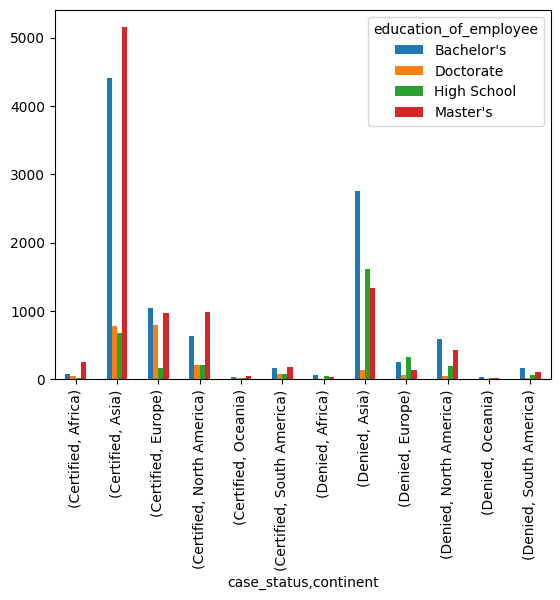

In [14]:
pd.crosstab(cols,cols3).plot(kind="bar")

<Axes: xlabel='case_status,continent'>

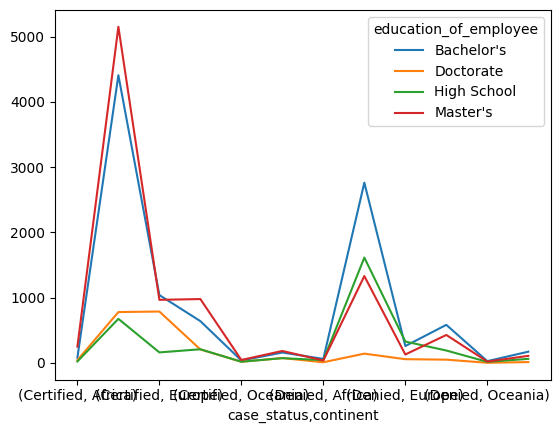

In [15]:
pd.crosstab(cols,cols3).plot(kind="line")

<Axes: ylabel='Frequency'>

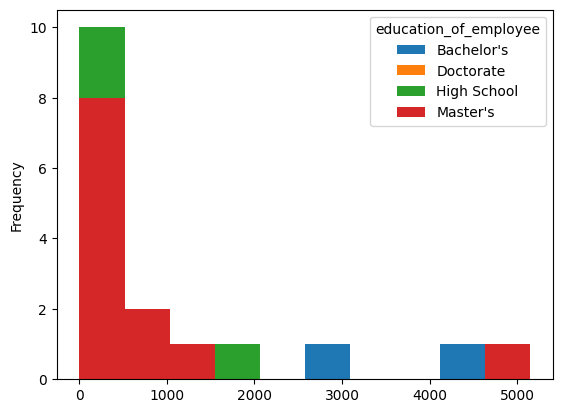

In [16]:
pd.crosstab(cols,cols3).plot(kind="hist")

<Axes: xlabel='case_status,continent'>

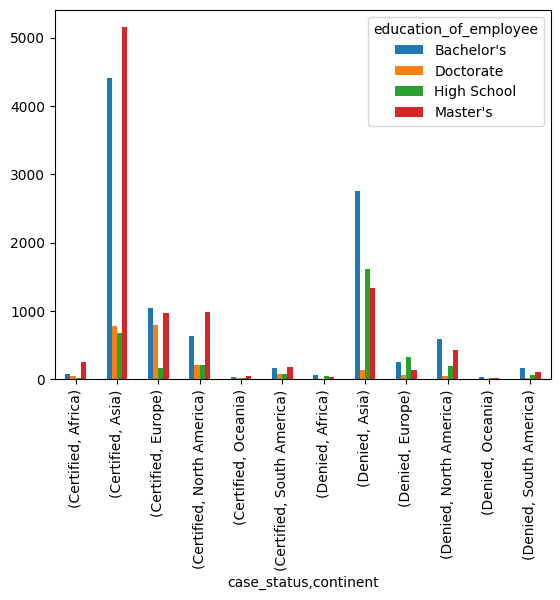

In [18]:
pd.crosstab(cols,cols3).plot(kind="bar")

In [ ]:
keys=df["continent"].value_counts().keys().tolist()

In [ ]:
for i in keys:
    df[df["continent"]==i]["prevailing_wage"].value_counts().keys()
    print(df)

In [ ]:
df.groupby('continent')["prevailing_wage"].mean()

# Group by 

In [33]:
con=df["continent"]=="Asia"
df[con]["prevailing_wage"].mean()

np.float64(79543.02178043414)

In [26]:
list(df.groupby("continent")["prevailing_wage"])[0]

('Africa',
 4        149907.39
 18       150441.13
 74        47170.76
 194      113637.40
 242       51886.04
            ...    
 25385     76348.20
 25408     55756.35
 25443       215.10
 25446     42353.45
 25474     51104.78
 Name: prevailing_wage, Length: 551, dtype: float64)

In [31]:
list(df.groupby("continent"))[0][1]["prevailing_wage"].mean()

np.float64(77425.92345027222)

In [55]:
df.groupby("continent")["prevailing_wage"].size()

continent
Africa             551
Asia             16861
Europe            3732
North America     3292
Oceania            192
South America      852
Name: prevailing_wage, dtype: int64

In [ ]:
df.groupby("")

In [51]:
list(df.groupby("education_of_employee"))[0][1]["no_of_employees"].min()

np.int64(-26)

- categorical 
- numerical
- cat vs cat
- cat vs num
- num vs num


# num vs num

 **plt.scatter**

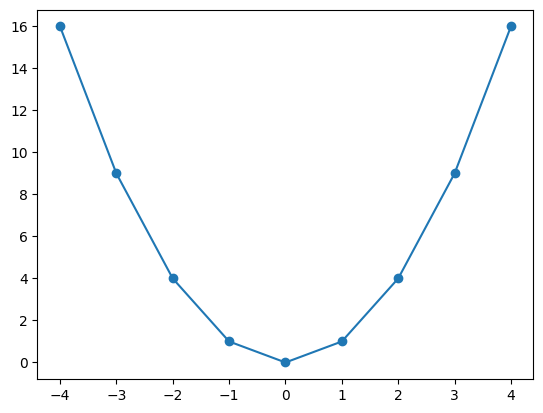

In [70]:
x=np.arange(-4,5)
y=x**2
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

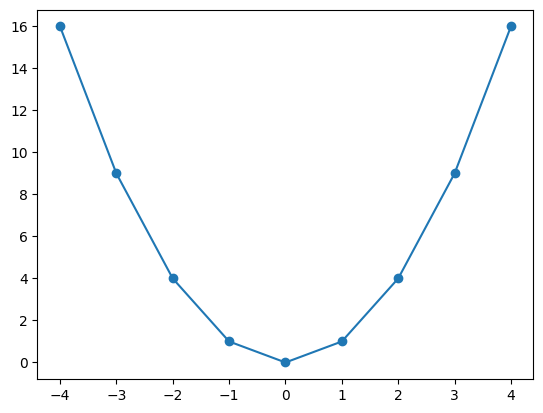

In [75]:
x=range(-4,5)
y=[i*i for i in x]
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

In [104]:
df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [105]:
col1=num["no_of_employees"]
col2=num["yr_of_estab"]
col3=num["prevailing_wage"]		

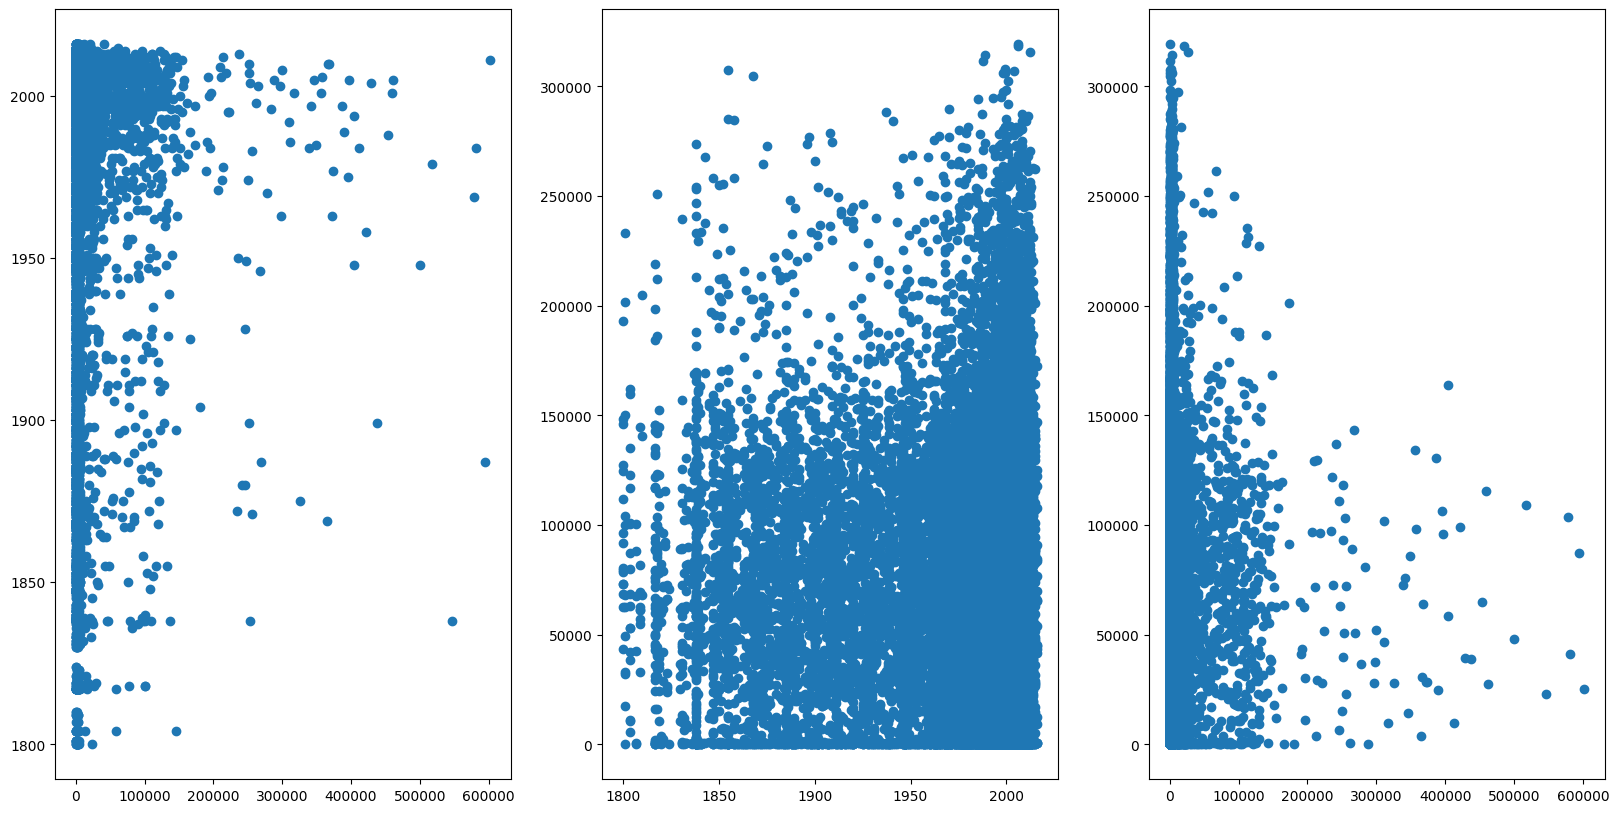

In [109]:
plt.figure(figsize=(20,10))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)

# Correlation

In [114]:
df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [112]:
vis_corr=df.corr(numeric_only=True)

<Axes: >

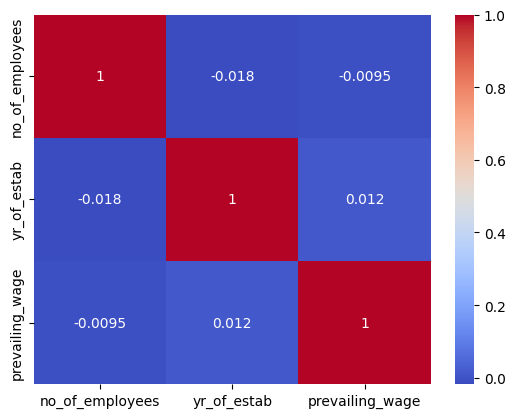

In [117]:
sns.heatmap(vis_corr,annot=True,cmap="coolwarm")

In [113]:
visa_cov=df.cov(numeric_only=True)